In [2]:
import hlv_engine
import json
import numpy as np
import os

# Define the run_id in Python so we can use it for the filenames later
CURRENT_RUN_ID = "run_001_v02_export"

# 1. Setup the locked context
context = hlv_engine.SimulationContext(
    run_id=CURRENT_RUN_ID,
    timestamp="2026-05-10T19:00:00Z", 
    git_commit_hash="dev",
    compiler_info="AppleClang", 
    platform_info="macOS ARM64",
    master_seed=42,
    projection_matrix_id="standard_icosahedral_tau",
    window_type="ball",
    window_parameters={"radius": 1.0, "sampling_radius_R6": 10.0},
    output_directory="../data/exports"
)

# 2. Run the Blazing-Fast C++ Engine
print("Sweeping 6D space... please wait.")
generator = hlv_engine.GLatticeGenerator(context)
generator.generate(10)

# 3. Trigger the Atomic Metadata Export in C++
context.export_metadata()

# 4. Extract arrays back to Python
physical_nodes = generator.get_physical_nodes()
internal_nodes = generator.get_internal_nodes()

# 5. Export CSVs using NumPy
export_dir = "../data/exports"
os.makedirs(export_dir, exist_ok=True)

# Use our Python variable instead of asking the C++ object!
phys_csv_path = os.path.join(export_dir, f"{CURRENT_RUN_ID}_physical_nodes.csv")
int_csv_path = os.path.join(export_dir, f"{CURRENT_RUN_ID}_internal_nodes.csv")

# Save as clean CSVs (comments="" removes the '#' from the header)
np.savetxt(phys_csv_path, physical_nodes, delimiter=",", header="x,y,z", comments="")
np.savetxt(int_csv_path, internal_nodes, delimiter=",", header="x_perp,y_perp,z_perp", comments="")

# 6. Print the victory output
print("\n✅ v0.2 EXPORT COMPLETE:")
print(f" - Metadata saved to: {export_dir}/{CURRENT_RUN_ID}_metadata.json")
print(f" - {len(physical_nodes)} physical nodes saved to: {phys_csv_path}")
print(f" - {len(internal_nodes)} internal nodes saved to: {int_csv_path}")

Sweeping 6D space... please wait.

✅ v0.2 EXPORT COMPLETE:
 - Metadata saved to: ../data/exports/run_001_v02_export_metadata.json
 - 76027 physical nodes saved to: ../data/exports/run_001_v02_export_physical_nodes.csv
 - 76027 internal nodes saved to: ../data/exports/run_001_v02_export_internal_nodes.csv


Generating 3D visualization... auto-scaling to full lattice size.


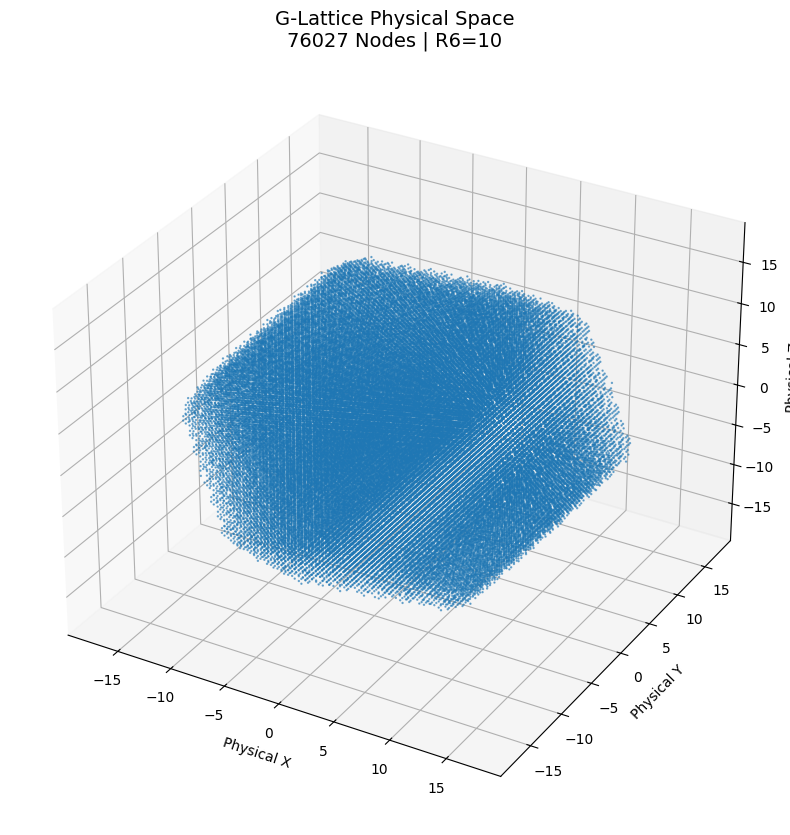

In [6]:
import matplotlib.pyplot as plt
import numpy as np

print("Generating 3D visualization... auto-scaling to full lattice size.")

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

physical_array = np.array(physical_nodes)
x = physical_array[:, 0]
y = physical_array[:, 1]
z = physical_array[:, 2]

ax.scatter(x, y, z, s=0.5, alpha=0.6, color='tab:blue')

# I REMOVED the set_xlim, set_ylim, set_zlim so it can zoom out naturally!

ax.set_xlabel('Physical X')
ax.set_ylabel('Physical Y')
ax.set_zlabel('Physical Z')
ax.set_title(f'G-Lattice Physical Space\n{len(physical_nodes)} Nodes | R6=10', fontsize=14)

# Save a high-res, standalone PNG to your figures folder
plt.savefig("../figures/lattice_visuals/v02_lattice_physical.png", dpi=300, bbox_inches='tight')

plt.show()